### Business Question: Which products are our bestsellers and when do customers buy most?

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv("OnlineRetail.csv", encoding = 'cp1252')

df

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,12/1/2010 8:26,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,12/1/2010 8:26,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
...,...,...,...,...,...,...,...,...
541904,581587,22613,PACK OF 20 SPACEBOY NAPKINS,12,12/9/2011 12:50,0.85,12680.0,France
541905,581587,22899,CHILDREN'S APRON DOLLY GIRL,6,12/9/2011 12:50,2.10,12680.0,France
541906,581587,23254,CHILDRENS CUTLERY DOLLY GIRL,4,12/9/2011 12:50,4.15,12680.0,France
541907,581587,23255,CHILDRENS CUTLERY CIRCUS PARADE,4,12/9/2011 12:50,4.15,12680.0,France


### Phase 1: Quick Data Quality Check

In [3]:
print(df[df.isin(["-"])].sum())

InvoiceNo        0
StockCode        0
Description      0
Quantity       0.0
InvoiceDate      0
UnitPrice      0.0
CustomerID     0.0
Country          0
dtype: object


In [4]:
df.isnull().sum()

InvoiceNo           0
StockCode           0
Description      1454
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     135080
Country             0
dtype: int64

### Phase 2: Clean Your Data

In [5]:
UK_df = df[df['Country'] == 'United Kingdom']

UK_df

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,12/1/2010 8:26,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,12/1/2010 8:26,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
...,...,...,...,...,...,...,...,...
541889,581585,22466,FAIRY TALE COTTAGE NIGHT LIGHT,12,12/9/2011 12:31,1.95,15804.0,United Kingdom
541890,581586,22061,LARGE CAKE STAND HANGING STRAWBERY,8,12/9/2011 12:49,2.95,13113.0,United Kingdom
541891,581586,23275,SET OF 3 HANGING OWLS OLLIE BEAK,24,12/9/2011 12:49,1.25,13113.0,United Kingdom
541892,581586,21217,RED RETROSPOT ROUND CAKE TINS,24,12/9/2011 12:49,8.95,13113.0,United Kingdom


In [6]:
print(df["InvoiceNo"])

0         536365
1         536365
2         536365
3         536365
4         536365
           ...  
541904    581587
541905    581587
541906    581587
541907    581587
541908    581587
Name: InvoiceNo, Length: 541909, dtype: object


In [7]:
UK_df['TotalSales'] = UK_df['Quantity'] * UK_df['UnitPrice']

#UK_df['TotalSales'] = UK_df['Quantity'] * UK_df['UnitPrice']
UK_df

C:\Users\hp\AppData\Local\Temp\ipykernel_13256\2190435369.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  UK_df['TotalSales'] = UK_df['Quantity'] * UK_df['UnitPrice']


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,TotalSales
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,12/1/2010 8:26,2.55,17850.0,United Kingdom,15.30
1,536365,71053,WHITE METAL LANTERN,6,12/1/2010 8:26,3.39,17850.0,United Kingdom,20.34
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,12/1/2010 8:26,2.75,17850.0,United Kingdom,22.00
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,12/1/2010 8:26,3.39,17850.0,United Kingdom,20.34
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,12/1/2010 8:26,3.39,17850.0,United Kingdom,20.34
...,...,...,...,...,...,...,...,...,...
541889,581585,22466,FAIRY TALE COTTAGE NIGHT LIGHT,12,12/9/2011 12:31,1.95,15804.0,United Kingdom,23.40
541890,581586,22061,LARGE CAKE STAND HANGING STRAWBERY,8,12/9/2011 12:49,2.95,13113.0,United Kingdom,23.60
541891,581586,23275,SET OF 3 HANGING OWLS OLLIE BEAK,24,12/9/2011 12:49,1.25,13113.0,United Kingdom,30.00
541892,581586,21217,RED RETROSPOT ROUND CAKE TINS,24,12/9/2011 12:49,8.95,13113.0,United Kingdom,214.80


### Phase 3: Run Your Analysis

In [8]:
Top_quantity = UK_df.groupby('Description').agg({"Quantity" : "sum"}).sort_values(by = 'Quantity', ascending = False)


In [9]:
print(Top_quantity.iloc[ : 10 , :])

                                    Quantity
Description                                 
WORLD WAR 2 GLIDERS ASSTD DESIGNS      48326
JUMBO BAG RED RETROSPOT                43167
POPCORN HOLDER                         34365
ASSORTED COLOUR BIRD ORNAMENT          33679
WHITE HANGING HEART T-LIGHT HOLDER     33193
PACK OF 12 LONDON TISSUES              25307
PACK OF 72 RETROSPOT CAKE CASES        24702
VICTORIAN GLASS HANGING T-LIGHT        23242
BROCADE RING PURSE                     22801
ASSORTED COLOURS SILK FAN              20322


In [10]:
Top_sales = UK_df.groupby('Description').agg({'TotalSales' : 'sum'}).sort_values(by = 'TotalSales', ascending = False)

Top_sales

,TotalSales
Description,
DOTCOM POSTAGE,206245.480
REGENCY CAKESTAND 3 TIER,134405.940
WHITE HANGING HEART T-LIGHT HOLDER,93953.070
PARTY BUNTING,92501.730
JUMBO BAG RED RETROSPOT,84516.440
...,...
Bank Charges,-7175.639
CRUK Commission,-7933.430
Adjust bad debt,-11062.060


In [11]:
print(Top_sales.iloc[ : 10, :])

                                    TotalSales
Description                                   
DOTCOM POSTAGE                       206245.48
REGENCY CAKESTAND 3 TIER             134405.94
WHITE HANGING HEART T-LIGHT HOLDER    93953.07
PARTY BUNTING                         92501.73
JUMBO BAG RED RETROSPOT               84516.44
PAPER CHAIN KIT 50'S CHRISTMAS        61888.19
ASSORTED COLOUR BIRD ORNAMENT         54662.15
CHILLI LIGHTS                         52986.86
PICNIC BASKET WICKER 60 PIECES        39619.50
BLACK RECORD COVER FRAME              39387.00


In [12]:
Hour_df  = UK_df.copy()

Hour_df['InvoiceDate']

0          12/1/2010 8:26
1          12/1/2010 8:26
2          12/1/2010 8:26
3          12/1/2010 8:26
4          12/1/2010 8:26
               ...       
541889    12/9/2011 12:31
541890    12/9/2011 12:49
541891    12/9/2011 12:49
541892    12/9/2011 12:49
541893    12/9/2011 12:49
Name: InvoiceDate, Length: 495478, dtype: object

In [13]:
Hour_df['Hour'] = Hour_df['InvoiceDate'].str[-5 : -3]

Hour_df['Hour'].astype('int64')
 

0          8
1          8
2          8
3          8
4          8
          ..
541889    12
541890    12
541891    12
541892    12
541893    12
Name: Hour, Length: 495478, dtype: int64

In [14]:
grouped_hour = Hour_df.groupby('Hour').agg({'TotalSales' : 'sum'})

grouped_hour

,TotalSales
Hour,
6,-204.780
7,11074.690
8,185242.500
9,605771.321
10,1067120.071
11,955581.030
12,1141464.400
13,985829.460
14,918467.961


In [15]:
grouped_hour.loc['10' : '16'].sum()

TotalSales    6786563.662
dtype: float64

In [16]:
l = grouped_hour.iloc[4:10].sum()

print(l)

TotalSales    6109596.782
dtype: float64


In [17]:
n = grouped_hour.loc[:].sum()

print(n)

TotalSales    8187806.364
dtype: float64


In [18]:
print((l/n)*100)

TotalSales    74.618237
dtype: float64


In [19]:
Day_df = UK_df.copy()

Day_df

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,TotalSales
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,12/1/2010 8:26,2.55,17850.0,United Kingdom,15.30
1,536365,71053,WHITE METAL LANTERN,6,12/1/2010 8:26,3.39,17850.0,United Kingdom,20.34
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,12/1/2010 8:26,2.75,17850.0,United Kingdom,22.00
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,12/1/2010 8:26,3.39,17850.0,United Kingdom,20.34
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,12/1/2010 8:26,3.39,17850.0,United Kingdom,20.34
...,...,...,...,...,...,...,...,...,...
541889,581585,22466,FAIRY TALE COTTAGE NIGHT LIGHT,12,12/9/2011 12:31,1.95,15804.0,United Kingdom,23.40
541890,581586,22061,LARGE CAKE STAND HANGING STRAWBERY,8,12/9/2011 12:49,2.95,13113.0,United Kingdom,23.60
541891,581586,23275,SET OF 3 HANGING OWLS OLLIE BEAK,24,12/9/2011 12:49,1.25,13113.0,United Kingdom,30.00
541892,581586,21217,RED RETROSPOT ROUND CAKE TINS,24,12/9/2011 12:49,8.95,13113.0,United Kingdom,214.80


In [20]:
Day_df['Day'] = Day_df['InvoiceDate'].str[ 3: 4]

Day_df

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,TotalSales,Day
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,12/1/2010 8:26,2.55,17850.0,United Kingdom,15.30,1
1,536365,71053,WHITE METAL LANTERN,6,12/1/2010 8:26,3.39,17850.0,United Kingdom,20.34,1
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,12/1/2010 8:26,2.75,17850.0,United Kingdom,22.00,1
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,12/1/2010 8:26,3.39,17850.0,United Kingdom,20.34,1
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,12/1/2010 8:26,3.39,17850.0,United Kingdom,20.34,1
...,...,...,...,...,...,...,...,...,...,...
541889,581585,22466,FAIRY TALE COTTAGE NIGHT LIGHT,12,12/9/2011 12:31,1.95,15804.0,United Kingdom,23.40,9
541890,581586,22061,LARGE CAKE STAND HANGING STRAWBERY,8,12/9/2011 12:49,2.95,13113.0,United Kingdom,23.60,9
541891,581586,23275,SET OF 3 HANGING OWLS OLLIE BEAK,24,12/9/2011 12:49,1.25,13113.0,United Kingdom,30.00,9
541892,581586,21217,RED RETROSPOT ROUND CAKE TINS,24,12/9/2011 12:49,8.95,13113.0,United Kingdom,214.80,9


In [21]:
Grouped_day = Day_df.groupby('Day').agg({'TotalSales' : 'sum'})

Grouped_day

,TotalSales
Day,
/,1374598.900
0,539189.570
1,1568823.690
2,1231647.700
3,576995.510
4,477351.280
5,452569.752
6,457952.952
7,570236.820


In [22]:
Grouped_day = Grouped_day.drop(index = ['/', '0'])

Grouped_day

,TotalSales
Day,
1,1568823.690
2,1231647.700
3,576995.510
4,477351.280
5,452569.752
6,457952.952
7,570236.820
8,520981.590
9,417458.600


### Phase 4: Visualise ONE Key Finding

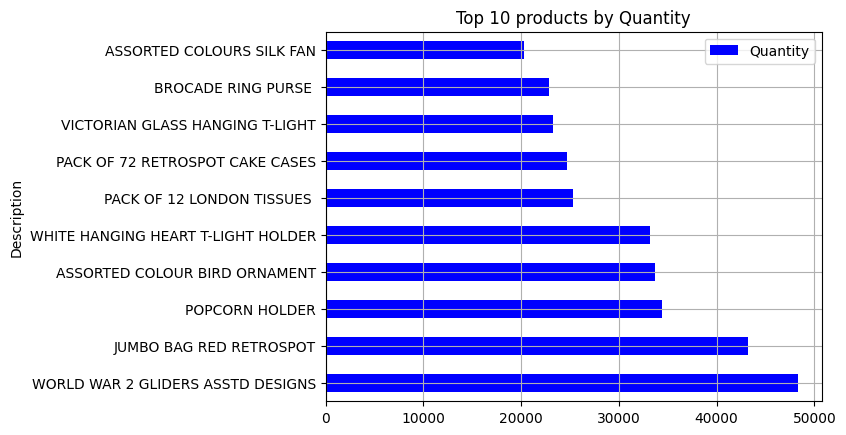

In [23]:
Top_quantity.iloc[ : 10 , :].plot(kind = 'barh', title = 'Top 10 products by Quantity', color = ['blue'] )
plt.grid()
plt.savefig('Top 10 products by quantity')
plt.show()

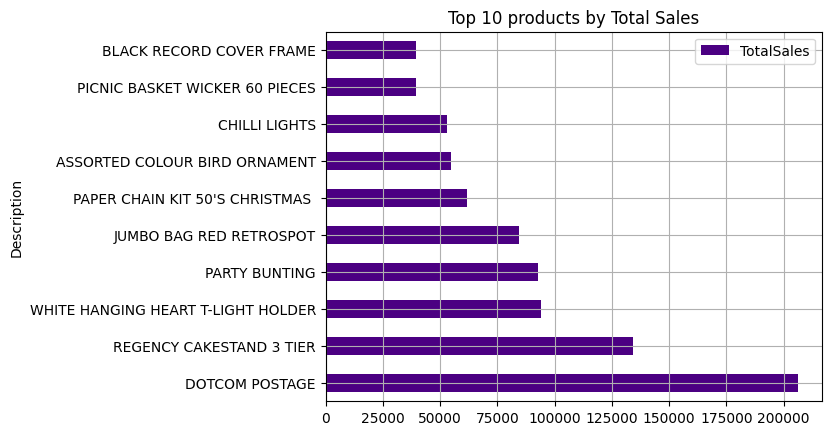

In [24]:
Top_sales.iloc[ : 10, :].plot(kind = 'barh', title = 'Top 10 products by Total Sales', color = ['indigo'] )
plt.grid()
plt.savefig('Top 10 products by total sales')
plt.show()

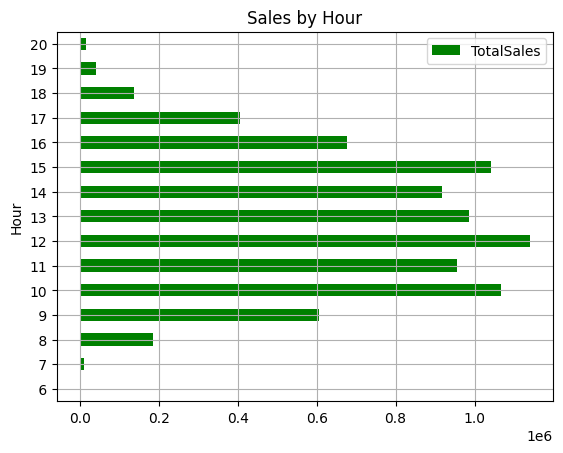

In [25]:
grouped_hour.plot(kind = 'barh', title = 'Sales by Hour', color = ['Green'] )
plt.grid()
plt.savefig('Sales per hour')
plt.show()

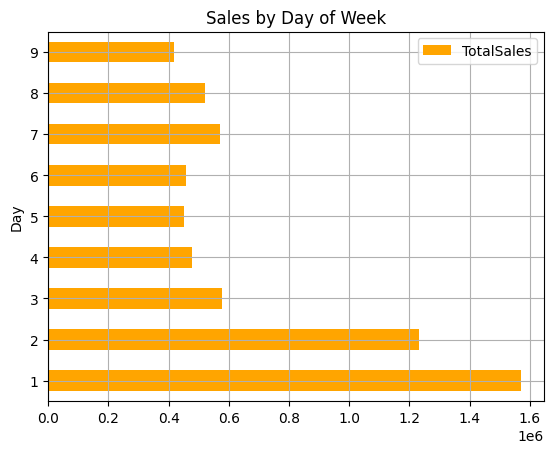

In [26]:
Grouped_day.plot(kind = 'barh', title = 'Sales by Day of Week', color = ['Orange'] )
plt.grid()
plt.savefig('Sales by day of week')
plt.show()

## Phase 5: Write Your Insight

In [27]:
insights = '''📊 Key Insights from the Sales Data Analysis

Highest-Selling Product by Quantity
WORLD WAR 2 GLIDERS ASSTD DESIGNS recorded the highest sales volume, with a total of 48,326 units sold, making it the most purchased product in the dataset.

Top Revenue-Generating Product
DOTCOM POSTAGE generated the highest revenue among all products, contributing 206,245.48 in total sales revenue.

Peak Revenue Hours
Sales activity is most concentrated between 10:00 AM and 3:00 PM, during which total revenue amounted to 6,109,596.78, accounting for approximately 74.6% of overall sales. This indicates that customer purchasing behavior is heavily skewed toward late morning and early afternoon hours
'''

In [28]:
with open('insights.txt', 'w', encoding="utf-8") as f:
    f.write(insights)

In [29]:
print(insights)

📊 Key Insights from the Sales Data Analysis

Highest-Selling Product by Quantity
WORLD WAR 2 GLIDERS ASSTD DESIGNS recorded the highest sales volume, with a total of 48,326 units sold, making it the most purchased product in the dataset.

Top Revenue-Generating Product
DOTCOM POSTAGE generated the highest revenue among all products, contributing 206,245.48 in total sales revenue.

Peak Revenue Hours
Sales activity is most concentrated between 10:00 AM and 3:00 PM, during which total revenue amounted to 6,109,596.78, accounting for approximately 74.6% of overall sales. This indicates that customer purchasing behavior is heavily skewed toward late morning and early afternoon hours

